<a href="https://colab.research.google.com/github/sohampalav/MyWebPage/blob/main/ML_EXP8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Soham vishram palav

Batch : CE3

Roll Number : CE34



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import scipy.spatial.distance as dist
from scipy.sparse.csgraph import minimum_spanning_tree
import networkx as nx

# Load dataset using sklearn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target  # 0 for Malignant, 1 for Benign

print("Dataset successfully loaded!")
display(df.head())

Dataset successfully loaded!


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
# Missing value checks
print("Missing Values:\n", df.isnull().sum().sum())

# Feature dimensions
print("\nDimensions of the dataset:", df.shape)

# Diagnosis class distribution (0 = Malignant, 1 = Benign)
print("\nDiagnosis class distribution:")
print(df['diagnosis'].value_counts())

# Summary statistics
display(df.describe())

Missing Values:
 0

Dimensions of the dataset: (569, 31)

Diagnosis class distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Separate features and target label
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized. Shape:", X_scaled.shape)

Features standardized. Shape: (569, 30)


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Compute pairwise Euclidean distance matrix
dist_matrix = dist.squareform(dist.pdist(X_scaled, metric='euclidean'))

print("Distance matrix shape:", dist_matrix.shape)
print("Sample distance matrix slice:")
print(dist_matrix[:5, :5])

Distance matrix shape: (569, 569)
Sample distance matrix slice:
[[ 0.         10.31849715  6.77763352 10.47267382  8.67103637]
 [10.31849715  0.          5.0320153  16.25073886  4.37888839]
 [ 6.77763352  5.0320153   0.         12.84472056  4.46222854]
 [10.47267382 16.25073886 12.84472056  0.         15.37530011]
 [ 8.67103637  4.37888839  4.46222854 15.37530011  0.        ]]


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Compute MST from the distance matrix
mst_sparse = minimum_spanning_tree(dist_matrix)
mst_matrix = mst_sparse.toarray()

# Create a NetworkX graph representation of the MST
G_mst = nx.from_scipy_sparse_array(mst_sparse)

print(f"MST contains {G_mst.number_of_nodes()} nodes and {G_mst.number_of_edges()} edges.")

MST contains 569 nodes and 568 edges.


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Extract edges and their weights
edges = list(G_mst.edges(data=True))

# Sort edges by weight in descending order
edges_sorted = sorted(edges, key=lambda x: x[2]['weight'], reverse=True)

# To partition into K=2 clusters, remove the largest K-1 edge (1 edge)
largest_edge = edges_sorted[0]
G_mst.remove_edge(largest_edge[0], largest_edge[1])

print(f"Removed edge between node {largest_edge[0]} and node {largest_edge[1]} with weight: {largest_edge[2]['weight']:.4f}")

# Extract the connected components representing our 2 clusters
components = list(nx.connected_components(G_mst))

# Assign final cluster labels
cluster_labels = np.zeros(len(df), dtype=int)
for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("Cluster allocation counts:", np.bincount(cluster_labels))

Removed edge between node 461 and node 503 with weight: 12.2999
Cluster allocation counts: [567   2]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Evaluate the clustering performance
sil_score = silhouette_score(X_scaled, cluster_labels)
ari_score = adjusted_rand_score(y, cluster_labels)
nmi_score = normalized_mutual_info_score(y, cluster_labels)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

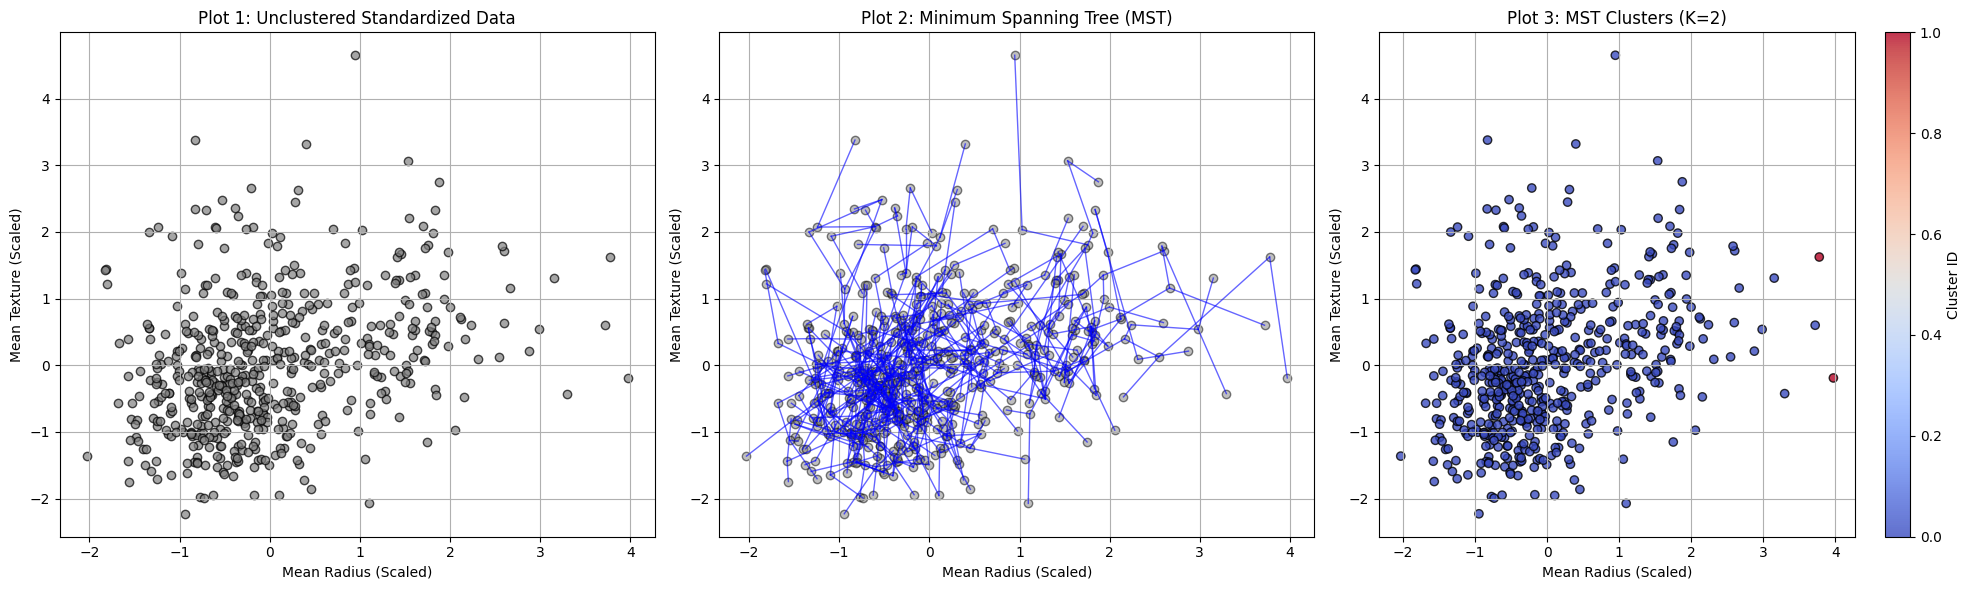

In [ ]:
# Select mean radius (index 0) and mean texture (index 1)
x_feature = X_scaled[:, 0]
y_feature = X_scaled[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Unclustered data points
axes[0].scatter(x_feature, y_feature, c='gray', alpha=0.7, edgecolors='k')
axes[0].set_title("Plot 1: Unclustered Standardized Data")
axes[0].set_xlabel("Mean Radius (Scaled)")
axes[0].set_ylabel("Mean Texture (Scaled)")
axes[0].grid(True)

# Plot 2: MST overlay
axes[1].scatter(x_feature, y_feature, c='gray', alpha=0.5, edgecolors='k')
# Re-instantiate complete MST graph before the edge cut for plotting
G_full_mst = nx.from_scipy_sparse_array(mst_sparse)
for u, v in G_full_mst.edges():
    axes[1].plot([x_feature[u], x_feature[v]], [y_feature[u], y_feature[v]], color='blue', alpha=0.6, linewidth=1)
axes[1].set_title("Plot 2: Minimum Spanning Tree (MST)")
axes[1].set_xlabel("Mean Radius (Scaled)")
axes[1].set_ylabel("Mean Texture (Scaled)")
axes[1].grid(True)

# Plot 3: Final clusters
scatter = axes[2].scatter(x_feature, y_feature, c=cluster_labels, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[2].set_title("Plot 3: MST Clusters (K=2)")
axes[2].set_xlabel("Mean Radius (Scaled)")
axes[2].set_ylabel("Mean Texture (Scaled)")
axes[2].grid(True)
fig.colorbar(scatter, ax=axes[2], label='Cluster ID')

plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.